Points found: 315


,timestep,XfrA_avg,XfrC_avg,Anode_current,Cathode_current,Anode_target,Cathode_target,VCell,BvA,BvC,BvE
0,0,0.950000,0.300000,-9.449560e-13,9.491930e-13,4.623150e-12,4.623150e-12,3.96978,-0.009975,3.95980,-0.1
1,1000,0.948464,0.301431,-4.299610e-12,4.515260e-12,4.623150e-12,4.623150e-12,3.86860,-0.006953,3.86165,-0.1
2,2000,0.946792,0.303240,-4.268740e-12,4.544240e-12,4.623150e-12,4.623150e-12,3.84529,-0.006772,3.83852,-0.1
3,3000,0.945103,0.305067,-4.268420e-12,4.547830e-12,4.623150e-12,4.623150e-12,3.82802,-0.006552,3.82146,-0.1
4,4000,0.943400,0.306899,-4.266470e-12,4.549270e-12,4.623150e-12,4.623150e-12,3.81339,-0.006332,3.80706,-0.1


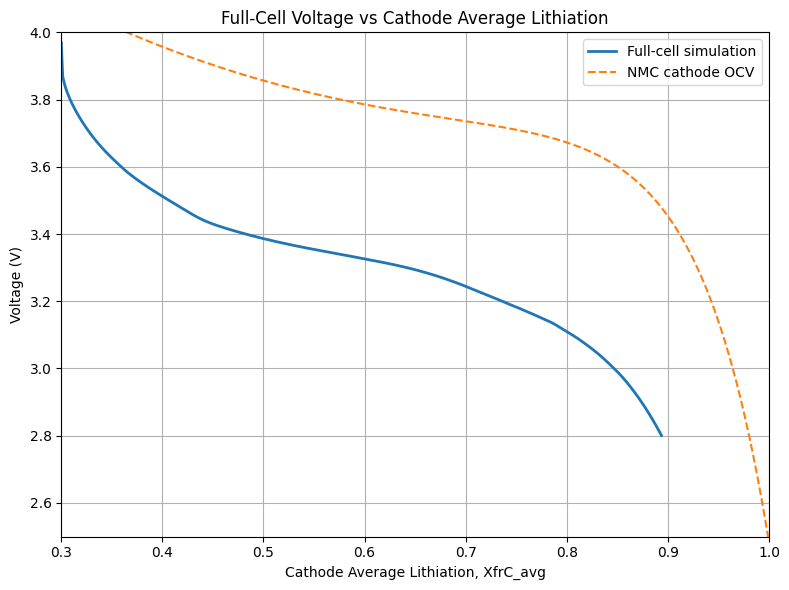

In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD THE FULL-CELL SLURM OUTPUT
# ============================================================

# # Option A: Paste your complete SLURM output between the triple quotes.
# log_text = r"""
# PASTE YOUR FULL SLURM OUTPUT HERE
# """

# Option B: Read the output directly from a file instead.
# Uncomment this section and update the path if preferred.
#
file_path = "../MSU_HPCC/full-cell-13794296.SLURMout"
with open(file_path, "r") as file:
    log_text = file.read()


# ============================================================
# STEP 2: PARSE FULL-CELL TIMESTEP LINES
# ============================================================

# This extracts values from lines such as:
#
# timestep: 1000 [FULL-CELL],
# XfrA_avg = 0.948638,
# XfrC_avg = 0.301501,
# Anode current = ...,
# Cathode current = ...,
# ...
# VCell = 3.86483,
# BvA = ...,
# BvC = ...,
# ...

timestep_pattern = re.compile(
    r"timestep:\s*(\d+)\s*\[FULL-CELL\],"
    r".*?XfrA_avg\s*=\s*([-+eE0-9.]+),"
    r".*?XfrC_avg\s*=\s*([-+eE0-9.]+),"
    r".*?Anode current\s*=\s*([-+eE0-9.]+),"
    r".*?Cathode current\s*=\s*([-+eE0-9.]+),"
    r".*?Anode target\s*=\s*([-+eE0-9.]+),"
    r".*?Cathode target\s*=\s*([-+eE0-9.]+),"
    r".*?VCell\s*=\s*([-+eE0-9.]+),"
    r".*?BvA\s*=\s*([-+eE0-9.]+),"
    r".*?BvC\s*=\s*([-+eE0-9.]+),"
    r".*?BvE\s*=\s*([-+eE0-9.]+)",
    # r".*?Ce_min\s*=\s*([-+eE0-9.]+),"
    # r".*?Ce_max\s*=\s*([-+eE0-9.]+)",
    re.MULTILINE
)

matches = timestep_pattern.findall(log_text)

columns = [
    "timestep",
    "XfrA_avg",
    "XfrC_avg",
    "Anode_current",
    "Cathode_current",
    "Anode_target",
    "Cathode_target",
    "VCell",
    "BvA",
    "BvC",
    "BvE",
    # "Ce_min",
    # "Ce_max",
]

df = pd.DataFrame(matches, columns=columns)

if df.empty:
    raise ValueError(
        "No full-cell timestep data were found. "
        "Check that the SLURM output was pasted into log_text."
    )

# Convert all extracted values to numbers.
df = df.astype(float)
df["timestep"] = df["timestep"].astype(int)

# Sort in case the output was not pasted chronologically.
df = df.sort_values("timestep").reset_index(drop=True)

print(f"Points found: {len(df)}")
display(df.head())


# ============================================================
# STEP 3: DEFINE THE NMC OCV FUNCTION
# ============================================================

def ocv_function(c):
    """
    NMC open-circuit voltage as a function of cathode lithiation.
    """
    c = np.asarray(c, dtype=float)

    return (
        1.095 * c**2
        - 8.234e-7 * np.exp(14.31 * c)
        + 4.692 * np.exp(-0.5389 * c)
    )


# Smooth OCV curve over the desired concentration range.
c_vals = np.linspace(0.01, 1.0, 500)
ocv_vals = ocv_function(c_vals)

# OCV evaluated at each simulated cathode lithiation.
df["NMC_OCV"] = ocv_function(df["XfrC_avg"])

# Difference between simulated full-cell voltage and cathode OCV.
df["VCell_minus_OCV"] = df["VCell"] - df["NMC_OCV"]


# ============================================================
# STEP 4: PLOT VCELL VS CATHODE AVERAGE LITHIATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    df["XfrC_avg"],
    df["VCell"],
    # marker="o",
    # markersize=2,
    linewidth=2,
    label="Full-cell simulation",
)

plt.plot(
    c_vals,
    ocv_vals,
    "--",
    linewidth=1.5,
    label="NMC cathode OCV",
)

plt.xlabel("Cathode Average Lithiation, XfrC_avg")
plt.ylabel("Voltage (V)")
plt.xlim(0.3, 1.0)
plt.ylim(2.5, 4.0)
plt.title("Full-Cell Voltage vs Cathode Average Lithiation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Points found: 315
   timestep  XfrA_avg  XfrC_avg  Anode_current  Cathode_current  Anode_target  \
0         0  0.950000  0.300000  -9.449560e-13     9.491930e-13  4.623150e-12   
1      1000  0.948464  0.301431  -4.299610e-12     4.515260e-12  4.623150e-12   
2      2000  0.946792  0.303240  -4.268740e-12     4.544240e-12  4.623150e-12   
3      3000  0.945103  0.305067  -4.268420e-12     4.547830e-12  4.623150e-12   
4      4000  0.943400  0.306899  -4.266470e-12     4.549270e-12  4.623150e-12   

   Cathode_target    VCell       BvA      BvC  BvE  
0    4.623150e-12  3.96978 -0.009975  3.95980 -0.1  
1    4.623150e-12  3.86860 -0.006953  3.86165 -0.1  
2    4.623150e-12  3.84529 -0.006772  3.83852 -0.1  
3    4.623150e-12  3.82802 -0.006552  3.82146 -0.1  
4    4.623150e-12  3.81339 -0.006332  3.80706 -0.1  

Maximum |XfrA_avg - (1 - XfrC_avg)|:
0.25154200000000004

Calculated voltage columns:
   XfrA_avg  XfrC_avg   NMC_OCV  Graphite_OCV  Full_Cell_OCV    VCell  \
0  0.950000  0.30

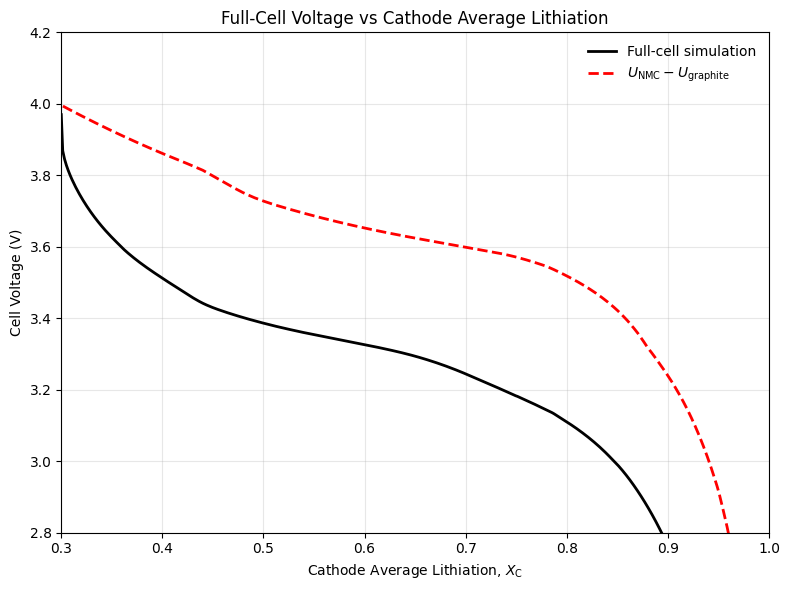

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# STEP 1: LOAD THE FULL-CELL SLURM OUTPUT
# ============================================================

file_path = "../MSU_HPCC/full-cell-13794296.SLURMout"

with open(file_path, "r") as file:
    log_text = file.read()


# ============================================================
# STEP 2: PARSE FULL-CELL TIMESTEP LINES
# ============================================================

timestep_pattern = re.compile(
    r"timestep:\s*(\d+)\s*\[FULL-CELL\],"
    r".*?XfrA_avg\s*=\s*([-+eE0-9.]+),"
    r".*?XfrC_avg\s*=\s*([-+eE0-9.]+),"
    r".*?Anode current\s*=\s*([-+eE0-9.]+),"
    r".*?Cathode current\s*=\s*([-+eE0-9.]+),"
    r".*?Anode target\s*=\s*([-+eE0-9.]+),"
    r".*?Cathode target\s*=\s*([-+eE0-9.]+),"
    r".*?VCell\s*=\s*([-+eE0-9.]+),"
    r".*?BvA\s*=\s*([-+eE0-9.]+),"
    r".*?BvC\s*=\s*([-+eE0-9.]+),"
    r".*?BvE\s*=\s*([-+eE0-9.]+)",
    re.MULTILINE
)

matches = timestep_pattern.findall(log_text)

columns = [
    "timestep",
    "XfrA_avg",
    "XfrC_avg",
    "Anode_current",
    "Cathode_current",
    "Anode_target",
    "Cathode_target",
    "VCell",
    "BvA",
    "BvC",
    "BvE",
]

df = pd.DataFrame(matches, columns=columns)

if df.empty:
    raise ValueError(
        "No full-cell timestep data were found. "
        "Check the SLURM file path and timestep output format."
    )

df = df.astype(float)
df["timestep"] = df["timestep"].astype(int)
df = df.sort_values("timestep").reset_index(drop=True)

print(f"Points found: {len(df)}")
print(df.head())


# ============================================================
# STEP 3: DEFINE THE NMC OCV FUNCTION
# ============================================================

def nmc_ocv(c):
    """
    NMC open-circuit voltage as a function of cathode lithiation.
    """
    c = np.asarray(c, dtype=float)

    return (
        1.095 * c**2
        - 8.234e-7 * np.exp(14.31 * c)
        + 4.692 * np.exp(-0.5389 * c)
    )


# ============================================================
# STEP 4: LOAD THE GRAPHITE OCV TABLE
# ============================================================

graphite_ticks = np.loadtxt(
    "../inputs/materials/C_Li_X_101.txt"
)

graphite_ocv_values = np.loadtxt(
    "../inputs/materials/C_Li_O3_101.txt"
)

# Sort the graphite table to ensure np.interp works correctly.
sort_indices = np.argsort(graphite_ticks)

graphite_ticks = graphite_ticks[sort_indices]
graphite_ocv_values = graphite_ocv_values[sort_indices]


def graphite_ocv(x):
    """
    Graphite open-circuit voltage as a function of anode lithiation.
    """
    x = np.asarray(x, dtype=float)

    # Keep interpolation points inside the tabulated range.
    x = np.clip(
        x,
        graphite_ticks.min(),
        graphite_ticks.max()
    )

    return np.interp(
        x,
        graphite_ticks,
        graphite_ocv_values
    )


# ============================================================
# STEP 5: CALCULATE THE FULL-CELL OCV CURVE
# ============================================================

# Cathode lithiation used as the horizontal coordinate.
xfrc_curve = np.linspace(0.01, 0.99, 500)

# Based on the specified full-cell relationship.
xfra_curve = 1.0 - xfrc_curve

nmc_ocv_curve = nmc_ocv(xfrc_curve)
graphite_ocv_curve = graphite_ocv(xfra_curve)

# Full-cell equilibrium voltage:
# cathode OCV minus anode OCV.
full_cell_ocv_curve = nmc_ocv_curve - graphite_ocv_curve


# ============================================================
# STEP 6: CALCULATE OCV AT SIMULATION POINTS
# ============================================================

# Use the modeled full-cell relationship requested here.
df["XfrA_from_XfrC"] = 1.0 - df["XfrC_avg"]

df["NMC_OCV"] = nmc_ocv(df["XfrC_avg"])

df["Graphite_OCV"] = graphite_ocv(
    df["XfrA_from_XfrC"]
)

df["Full_Cell_OCV"] = (
    df["NMC_OCV"]
    - df["Graphite_OCV"]
)

# Difference between the simulated voltage and equilibrium
# full-cell OCV. This represents the net polarization/overpotential.
df["VCell_minus_Full_Cell_OCV"] = (
    df["VCell"]
    - df["Full_Cell_OCV"]
)


# ============================================================
# OPTIONAL: CHECK THE XfrA = 1 - XfrC ASSUMPTION
# ============================================================

df["Lithiation_balance_error"] = (
    df["XfrA_avg"]
    - df["XfrA_from_XfrC"]
)

print("\nMaximum |XfrA_avg - (1 - XfrC_avg)|:")
print(df["Lithiation_balance_error"].abs().max())

print("\nCalculated voltage columns:")
print(
    df[
        [
            "XfrA_avg",
            "XfrC_avg",
            "NMC_OCV",
            "Graphite_OCV",
            "Full_Cell_OCV",
            "VCell",
            "VCell_minus_Full_Cell_OCV",
        ]
    ].head()
)


# ============================================================
# STEP 7: PLOT VCELL AND FULL-CELL OCV
# ============================================================

plt.figure(figsize=(8, 6))

# Simulated full-cell voltage.
plt.plot(
    df["XfrC_avg"],
    df["VCell"],
    color="black",
    linewidth=2,
    label="Full-cell simulation",
)

# Equilibrium full-cell OCV.
plt.plot(
    xfrc_curve,
    full_cell_ocv_curve,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$U_{\mathrm{NMC}} - U_{\mathrm{graphite}}$",
)

plt.xlabel("Cathode Average Lithiation, $X_{\\mathrm{C}}$")
plt.ylabel("Cell Voltage (V)")
plt.xlim(0.3, 1.0)
plt.ylim(2.8, 4.2)
plt.title("Full-Cell Voltage vs Cathode Average Lithiation")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


File: ../MSU_HPCC/NMC-Graphite-Full-altered-14793504.SLURMout
Points found: 247
   timestep  XfrA_avg  XfrC_avg  Anode_current  Cathode_current  Anode_target  \
0         0  0.950000  0.300000  -9.793420e-13     9.453230e-12  4.623150e-12   
1      1000  0.949921  0.300234  -3.921300e-12     4.556970e-12  4.623150e-12   
2      2000  0.949778  0.300415  -4.421380e-12     4.391770e-12  4.623150e-12   
3      3000  0.949629  0.300596  -4.474730e-12     4.392860e-12  4.623150e-12   
4      4000  0.949476  0.300776  -4.531960e-12     4.392850e-12  4.623150e-12   

   Cathode_target    VCell       BvA      BvC  BvE  
0    4.623150e-12  3.97002 -0.009997  3.96002 -0.1  
1    4.623150e-12  3.97801 -0.007498  3.97051 -0.1  
2    4.623150e-12  3.97637 -0.007062  3.96931 -0.1  
3    4.623150e-12  3.97483 -0.007000  3.96783 -0.1  
4    4.623150e-12  3.97346 -0.006937  3.96652 -0.1  

File: ../MSU_HPCC/full-cell-1.0-13871987.SLURMout
Points found: 315
   timestep  XfrA_avg  XfrC_avg  Anode_curren

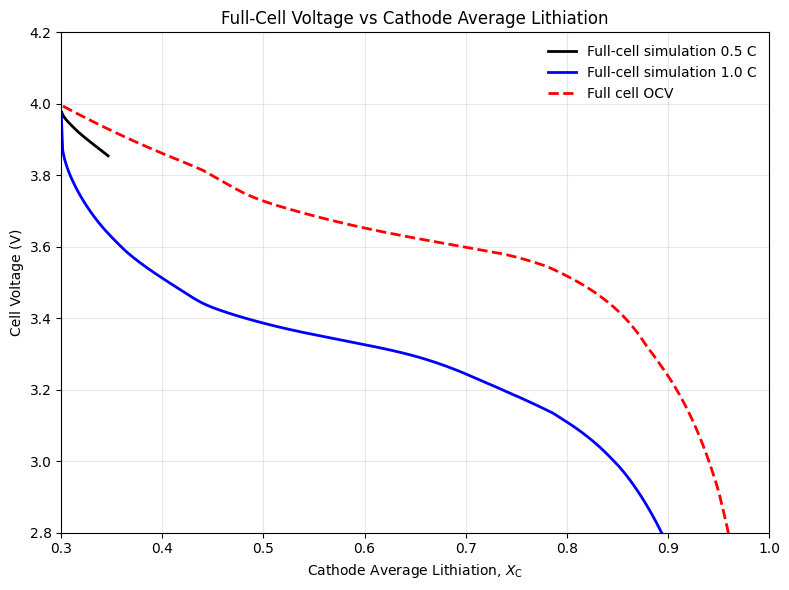

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# STEP 1: DEFINE THE FULL-CELL SLURM FILES
# ============================================================

file_path_1 = "../MSU_HPCC/NMC-Graphite-Full-altered-14793504.SLURMout"
file_path_2 = "../MSU_HPCC/full-cell-1.0-13871987.SLURMout"


# ============================================================
# STEP 2: DEFINE THE FULL-CELL TIMESTEP PATTERN
# ============================================================

timestep_pattern = re.compile(
    r"timestep:\s*(\d+)\s*\[FULL-CELL\],"
    r".*?XfrA_avg\s*=\s*([-+eE0-9.]+),"
    r".*?XfrC_avg\s*=\s*([-+eE0-9.]+),"
    r".*?Anode current\s*=\s*([-+eE0-9.]+),"
    r".*?Cathode current\s*=\s*([-+eE0-9.]+),"
    r".*?Anode target\s*=\s*([-+eE0-9.]+),"
    r".*?Cathode target\s*=\s*([-+eE0-9.]+),"
    r".*?VCell\s*=\s*([-+eE0-9.]+),"
    r".*?BvA\s*=\s*([-+eE0-9.]+),"
    r".*?BvC\s*=\s*([-+eE0-9.]+),"
    r".*?BvE\s*=\s*([-+eE0-9.]+)",
    re.MULTILINE
)

columns = [
    "timestep",
    "XfrA_avg",
    "XfrC_avg",
    "Anode_current",
    "Cathode_current",
    "Anode_target",
    "Cathode_target",
    "VCell",
    "BvA",
    "BvC",
    "BvE",
]


# ============================================================
# STEP 3: LOAD AND PARSE A FULL-CELL SLURM FILE
# ============================================================

def load_full_cell_data(file_path):
    """
    Load and parse one BESFEM full-cell SLURM output file.
    """
    with open(file_path, "r") as file:
        log_text = file.read()

    matches = timestep_pattern.findall(log_text)

    df = pd.DataFrame(matches, columns=columns)

    if df.empty:
        raise ValueError(
            f"No full-cell timestep data were found in:\n{file_path}\n"
            "Check the file path and timestep output format."
        )

    df = df.astype(float)
    df["timestep"] = df["timestep"].astype(int)

    df = (
        df.sort_values("timestep")
        .drop_duplicates(subset="timestep", keep="last")
        .reset_index(drop=True)
    )

    print(f"\nFile: {file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df


# Load both full-cell simulations.
df1 = load_full_cell_data(file_path_1)
df2 = load_full_cell_data(file_path_2)


# ============================================================
# STEP 4: DEFINE THE NMC OCV FUNCTION
# ============================================================

def nmc_ocv(c):
    """
    NMC open-circuit voltage as a function of cathode lithiation.
    """
    c = np.asarray(c, dtype=float)

    return (
        1.095 * c**2
        - 8.234e-7 * np.exp(14.31 * c)
        + 4.692 * np.exp(-0.5389 * c)
    )


# ============================================================
# STEP 5: LOAD THE GRAPHITE OCV TABLE
# ============================================================

graphite_ticks = np.loadtxt(
    "../inputs/materials/C_Li_X_101.txt"
)

graphite_ocv_values = np.loadtxt(
    "../inputs/materials/C_Li_O3_101.txt"
)

# np.interp requires the interpolation coordinates to be increasing.
sort_indices = np.argsort(graphite_ticks)

graphite_ticks = graphite_ticks[sort_indices]
graphite_ocv_values = graphite_ocv_values[sort_indices]


def graphite_ocv(x):
    """
    Graphite open-circuit voltage as a function of anode lithiation.
    """
    x = np.asarray(x, dtype=float)

    x = np.clip(
        x,
        graphite_ticks.min(),
        graphite_ticks.max()
    )

    return np.interp(
        x,
        graphite_ticks,
        graphite_ocv_values
    )


# ============================================================
# STEP 6: CALCULATE THE FULL-CELL OCV CURVE
# ============================================================

# Cathode lithiation is used for the horizontal axis.
xfrc_curve = np.linspace(0.01, 0.99, 500)

# Assumed electrode lithiation relationship.
xfra_curve = 1.0 - xfrc_curve

nmc_ocv_curve = nmc_ocv(xfrc_curve)
graphite_ocv_curve = graphite_ocv(xfra_curve)

# Full-cell equilibrium voltage.
full_cell_ocv_curve = (
    nmc_ocv_curve
    - graphite_ocv_curve
)


# ============================================================
# STEP 7: CALCULATE OCV VALUES FOR EACH SIMULATION
# ============================================================

def add_ocv_columns(df):
    """
    Add NMC, graphite, and full-cell OCV values to a DataFrame.
    """
    df = df.copy()

    df["XfrA_from_XfrC"] = 1.0 - df["XfrC_avg"]

    df["NMC_OCV"] = nmc_ocv(
        df["XfrC_avg"]
    )

    df["Graphite_OCV"] = graphite_ocv(
        df["XfrA_from_XfrC"]
    )

    df["Full_Cell_OCV"] = (
        df["NMC_OCV"]
        - df["Graphite_OCV"]
    )

    df["VCell_minus_Full_Cell_OCV"] = (
        df["VCell"]
        - df["Full_Cell_OCV"]
    )

    df["Lithiation_balance_error"] = (
        df["XfrA_avg"]
        - df["XfrA_from_XfrC"]
    )

    return df


df1 = add_ocv_columns(df1)
df2 = add_ocv_columns(df2)


# ============================================================
# STEP 8: PRINT LITHIATION-BALANCE CHECKS
# ============================================================

print("\nSimulation 1 maximum lithiation-balance error:")
print(
    df1["Lithiation_balance_error"]
    .abs()
    .max()
)

print("\nSimulation 2 maximum lithiation-balance error:")
print(
    df2["Lithiation_balance_error"]
    .abs()
    .max()
)


# ============================================================
# STEP 9: PLOT BOTH SIMULATIONS AND THE FULL-CELL OCV
# ============================================================

plt.figure(figsize=(8, 6))

# First simulation.
plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    color="black",
    linewidth=2,
    label="Full-cell simulation 0.5 C",
)

# Second simulation.
plt.plot(
    df2["XfrC_avg"],
    df2["VCell"],
    color="blue",
    linewidth=2,
    label="Full-cell simulation 1.0 C",
)

# Full-cell equilibrium OCV.
plt.plot(
    xfrc_curve,
    full_cell_ocv_curve,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"Full cell OCV",
)

plt.xlabel(
    r"Cathode Average Lithiation, $X_{\mathrm{C}}$"
)
plt.ylabel("Cell Voltage (V)")

plt.xlim(0.3, 1.0)
plt.ylim(2.8, 4.2)

plt.title(
    "Full-Cell Voltage vs Cathode Average Lithiation"
)

plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()